In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

titanic_data = pd.read_csv('Titanic.csv')


titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [25]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [26]:
titanic_data.drop("Cabin" , axis=1 , inplace=True)

In [27]:
titanic_data.dropna(inplace=True)

<Axes: >

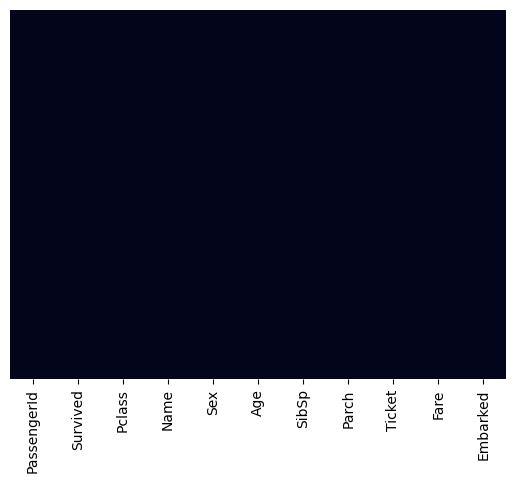

In [28]:
sns.heatmap(titanic_data.isnull() , yticklabels=False , cbar=False)

In [29]:
sex = pd.get_dummies(titanic_data['Sex'], drop_first=True, dtype=int)
sex.head()

,male
0,1
1,0
2,1
3,1
4,0


In [30]:
embark = pd.get_dummies(titanic_data['Embarked'], drop_first=True, dtype=int)
embark.head()

,Q,S
0,1,0
1,0,1
2,1,0
3,0,1
4,0,1


In [31]:
pcl = pd.get_dummies(titanic_data['Pclass'], prefix='Pclass', drop_first=True, dtype=int)
pcl.head()

,Pclass_2,Pclass_3
0,0,1
1,0,1
2,1,0
3,0,1
4,0,1


In [32]:
titanic_data=pd.concat([titanic_data, sex, embark, pcl], axis=1)

In [33]:
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S,Pclass_2,Pclass_3
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,1,1,0,0,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0,0,1,0,1
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,1,1,0,1,0
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,1,0,1,0,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0,0,1,0,1
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,S,1,0,1,0,1
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,Q,0,1,0,0,1
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,S,1,0,1,1,0
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,C,0,0,0,0,1
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,S,1,0,1,0,1


In [34]:
titanic_data.drop(['Sex' , 'Pclass' , 'Embarked' , 'PassengerId' , 'Name' , 'Ticket'], axis=1, inplace=True)

In [35]:
titanic_data.head(10)

,Survived,Age,SibSp,Parch,Fare,male,Q,S,Pclass_2,Pclass_3
0,0,34.5,0,0,7.8292,1,1,0,0,1
1,1,47.0,1,0,7.0000,0,0,1,0,1
2,0,62.0,0,0,9.6875,1,1,0,1,0
3,0,27.0,0,0,8.6625,1,0,1,0,1
4,1,22.0,1,1,12.2875,0,0,1,0,1
5,0,14.0,0,0,9.2250,1,0,1,0,1
6,1,30.0,0,0,7.6292,0,1,0,0,1
7,0,26.0,1,1,29.0000,1,0,1,1,0
8,1,18.0,0,0,7.2292,0,0,0,0,1
9,0,21.0,2,0,24.1500,1,0,1,0,1


In [36]:
# Entrainement
X= titanic_data.drop("Survived" , axis=1)
y= titanic_data["Survived"]

In [37]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [38]:
from sklearn.neighbors import KNeighborsClassifier


In [39]:
# modèle KNN
knn = KNeighborsClassifier(n_neighbors=2,metric='manhattan')
knn.fit(X_train, y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [43]:
predictions = knn.predict(X_test)
print(predictions)

[0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [42]:
print("la personee est : 

la personee est :  [0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
